## Civic Issue Image Classifier - Local GPU Training with Google Drive

This notebook is configured for **local Jupyter Notebook with GPU**, using **Google Drive for Desktop** for dataset storage.

### 📁 Dataset Structure (on Google Drive):
```
G:\My Drive\civic_issue_classification\
└── dataset/
    ├── train/
    │   ├── electricpoles/
    │   ├── fallentrees/
    │   ├── garbage/
    │   ├── miscellaneous/
    │   └── pothole/
    ├── val/
    │   └── (same subdirs)
    └── test/
        └── (same subdirs)
```

### 🏷️ Classes:
| Folder Name | Display Name | Description |
|-------------|--------------|-------------|
| electricpoles | electric_poles | Damaged/fallen electric poles |
| fallentrees | fallen_trees | Fallen trees blocking roads |
| garbage | garbage | Garbage/waste on streets |
| pothole | pothole | Road potholes |
| miscellaneous | miscellaneous | Images not matching above categories |

### ✅ Features:
- Google Drive for Desktop integration (no large file transfers)
- Optimized data pipeline with `tf.data.AUTOTUNE` prefetch
- Reproducibility with random seeds
- Learning rate scheduler for better convergence
- Early stopping with patience=5
- Saves model in both `.keras` and `.h5` formats

### 🚀 To Train:
1. Install Google Drive for Desktop and sync your dataset
2. Check the drive letter (usually G:) and update if needed
3. Run all cells from top to bottom
4. Model will be saved locally to `Backend/model/` folder

**BUILDING AN IMAGE CLASSIFIER WHICH CLASSIFIES IMAGES INTO SEVERAL CIVIC CATEGORIES LIKE GARBAGE, POTHOLES, ETC.**

**IMPORTING REQUIREMENTS**

In [ ]:
# =====================================================
# IMPORTS AND REPRODUCIBILITY SETUP
# =====================================================
import tensorflow as tf
import keras
import random
import numpy as np

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version: {keras.__version__}")


TensorFlow Version: 2.15.0
Keras Version: 2.15.0


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# =====================================================
# DEFINE PATHS
# =====================================================
# Choose your data source:
USE_GOOGLE_DRIVE = True  # Set to False to use local dataset

if USE_GOOGLE_DRIVE:
    # =====================================================
    # GOOGLE DRIVE FOR DESKTOP
    # =====================================================
    # Check your File Explorer for the drive letter (usually G:)
    DRIVE_LETTER = "G"  # Change if your Drive is on a different letter
    DRIVE_BASE = f"{DRIVE_LETTER}:\\My Drive\\civic_issue_classification"
    BASE_DIR = DRIVE_BASE
    
    TRAIN_DIR = os.path.join(DRIVE_BASE, "dataset", "train")
    VAL_DIR = os.path.join(DRIVE_BASE, "dataset", "val")
    TEST_DIR = os.path.join(DRIVE_BASE, "dataset", "test")
    
    print("☁️ Using Google Drive for Desktop")
    print(f"   Drive letter: {DRIVE_LETTER}:")
else:
    # =====================================================
    # LOCAL DATASET
    # =====================================================
    LOCAL_BASE = r"E:\My Programs\civic_issue_classification"
    BASE_DIR = LOCAL_BASE
    
    TRAIN_DIR = os.path.join(LOCAL_BASE, "dataset", "train")
    VAL_DIR = os.path.join(LOCAL_BASE, "dataset", "val")
    TEST_DIR = os.path.join(LOCAL_BASE, "dataset", "test")
    
    print("💻 Using local dataset")

# Model save path (always save locally for backend)
MODEL_SAVE_DIR = r"E:\My Programs\civic_issue_classification\Backend\model"
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

print(f"\n📂 Train directory: {TRAIN_DIR}")
print(f"📂 Val directory: {VAL_DIR}")
print(f"📂 Test directory: {TEST_DIR}")
print(f"💾 Model save directory: {MODEL_SAVE_DIR}")

# Verify directories exist
print("\n🔍 Checking directories...")
all_found = True
for d in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if os.path.exists(d):
        print(f"✅ Found: {d}")
    else:
        print(f"❌ Missing: {d}")
        all_found = False

if not all_found and USE_GOOGLE_DRIVE:
    print("\n⚠️ Make sure:")
    print("   1. Google Drive for Desktop is installed and running")

    print("   2. Your Drive is synced")    print(f"   3. Drive letter is correct (currently set to {DRIVE_LETTER}:)")

In [ ]:
print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)

# Check GPU availability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU available: {gpus}")
    # Enable memory growth to avoid OOM
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("⚠️ No GPU found - training will be slow!")

print(f"\n📊 Environment ready for training!")

TensorFlow version: 2.15.0
Keras version: 2.15.0
GPU available: []
✅ Environment is compatible with ml-service (TensorFlow 2.15.0 + Keras 2.15.0)


**CALLING DATA FROM FILES**

In [ ]:
img_size = (224, 224)
batch_size = 32  # Optimized for GPU training

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=False
)

print(f"✅ Loaded datasets from {BASE_DIR}")

Found 24571 files belonging to 4 classes.
Found 3374 files belonging to 4 classes.
Found 2666 files belonging to 4 classes.


In [ ]:
# =====================================================
# CLASS NAME MAPPING
# =====================================================
# Folder names from dataset (don't change these unless you rename folders)
folder_names = train_ds.class_names
print("Folder names (from dataset):", folder_names)

# Display names mapping (folder_name -> display_name)
# CHANGE DISPLAY NAMES HERE - folder names stay the same
CLASS_NAME_MAP = {
    'electricpoles': 'electric_poles',
    'fallentrees': 'fallen_trees',
    'garbage': 'garbage',
    'miscellaneous': 'miscellaneous',
    'pothole': 'pothole'
}

# Create display names list (in same order as folder_names)
class_names = [CLASS_NAME_MAP.get(name, name) for name in folder_names]
print("Display names (for output):", class_names)

# Reverse mapping for when you need folder name from display name
DISPLAY_TO_FOLDER = {v: k for k, v in CLASS_NAME_MAP.items()}

print(f"\n✅ {len(class_names)} classes configured")

Classes: ['electricpoles', 'fallentrees', 'garbage', 'pothole']


**NORMALIZATION AND AUGMENTATION OF DATA**

In [9]:
# General augmentation for all classes
general_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

# Stronger augmentation dedicated to garbage class
# garbage_augmentation = tf.keras.Sequential([
#     layers.RandomFlip("horizontal"),
#     layers.RandomRotation(0.2),
#     layers.RandomZoom(0.2),
#     layers.RandomContrast(0.2),
# ])


In [ ]:
normalization_layer = layers.Rescaling(1./255)

# Use AUTOTUNE for optimal prefetching
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    train_ds
    .map(lambda x, y: (general_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    .map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
    .shuffle(1000)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
    .cache()  # Cache validation data for faster epochs
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds
    .map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
    .cache()  # Cache test data
    .prefetch(AUTOTUNE)
)

print("✅ Data pipeline configured with AUTOTUNE prefetching")

**TRIED AUGMENTING(OVERSAMPLING) GARBAGE CLASS**

In [7]:
# garbage_ds = train_ds_raw.unbatch().filter(
#     lambda x, y: tf.equal(tf.argmax(y), garbage_index)
# )

# garbage_ds = garbage_ds.batch(batch_size)
# garbage_ds = garbage_ds.map(lambda x, y: (normalization_layer(x), y))
# garbage_ds = garbage_ds.map(lambda x, y: (garbage_augmentation(x, training=True), y))

# # Merge augmented garbage back
# train_ds = train_ds.concatenate(garbage_ds)


**BUILDING MODEL AND USING TRANSFER LEARNING**

**1. CUSTOM CNN**

In [8]:
# def build_civic_cnn(input_shape=(224,224,3), num_classes=4):
#     inputs = layers.Input(shape=input_shape)
#     model = models.Sequential([
#         layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
#         layers.MaxPooling2D((2,2)),

#         layers.Conv2D(64, (3,3), activation='relu'),
#         layers.MaxPooling2D((2,2)),

#         layers.Conv2D(128, (3,3), activation='relu'),
#         layers.MaxPooling2D((2,2)),

#         layers.Conv2D(256, (3,3), activation='relu'),
#         layers.MaxPooling2D((2,2)),

#         #layers.Flatten(),
#         layers.GlobalAveragePooling2D(),
#         layers.Dense(128, activation='relu'),
#         layers.Dropout(0.5),
#         layers.Dense(num_classes, activation='softmax')
#     ])
#     model.compile(optimizer='adam',
#                   loss='categorical_crossentropy',
#                   metrics=['accuracy'])
#     return model

# model = build_civic_cnn()
# model.summary()


**ADDING CLASS WEIGHTS AND MENTIONING CHECKPOINTS AND EARLYSTOP**


In [ ]:
# RAW training dataset (ONLY for class weights calculation)
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=False
)

Found 24571 files belonging to 4 classes.


In [ ]:
#Adding class weights so that the balance is maintained between classes
# ===============================
# CLASS WEIGHTS
# ===============================

from sklearn.utils import class_weight
import numpy as np

labels = []

assert train_ds_raw is not None, "train_ds_raw must be defined before computing class weights"
for _, y in train_ds_raw.unbatch():
    if len(y.shape) > 0:          # one-hot
        labels.append(int(np.argmax(y.numpy())))
    else:                         # integer labels
        labels.append(int(y.numpy()))

unique_classes = np.arange(len(class_names))

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=labels
)

class_weights = dict(zip(unique_classes, class_weights))
print("Class Weights:", class_weights)

#*******************************************************************************
#Calculating steps per epoch
# train_steps = tf.data.experimental.cardinality(train_ds).numpy()
# steps_per_epoch = train_steps
# print("Steps per epoch:", steps_per_epoch)
#*******************************************************************************

# ===============================
# CALLBACKS
# ===============================
# Checkpoint - save best model
checkpoint_path = os.path.join(MODEL_SAVE_DIR, "best_model.keras")
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Early stopping with better patience
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Learning rate scheduler - reduce LR when plateau
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# All callbacks combined
callbacks_list = [checkpoint, early_stop, lr_scheduler]

print(f"✅ Callbacks configured. Model will be saved to: {checkpoint_path}")

Class Weights: {0: 0.8448287718333104, 1: 0.7226764705882353, 2: 1.9606607085860197, 3: 1.083950944062114}


**1.1 FITTING MODEL**

In [11]:
# history = model.fit(
#     train_ds,
#     validation_data=val_ds,
#     epochs=8,
#     class_weight=class_weights,
#     steps_per_epoch = steps_per_epoch,
#     callbacks=[early_stop, checkpoint]
# )

In [12]:
# model.save("civic_issue_model_customCNN.keras")

**1.2 PLOTTING THE LEARNINGS MADE**

In [13]:
# plt.plot(history.history['accuracy'], label='train acc')
# plt.plot(history.history['val_accuracy'], label='val acc')
# plt.legend()
# plt.show()

# plt.plot(history.history['loss'], label='train loss')
# plt.plot(history.history['val_loss'], label='val loss')
# plt.legend()
# plt.show()


**1.3 TESTING MODEL PERFORMANCE ON TEST_DATA**

In [14]:
# test_loss, test_acc = model.evaluate(test_ds)   #testing model performance on the test data set
# print("Test Accuracy:", test_acc)


**1.4 LET's TRY A DEMO IMAGE AND SEE HOW MODEL CLASSIFIES IT**

In [15]:
# from tensorflow.keras.preprocessing import image

# class_names = train_ds.class_names
# print("Class names:", class_names)

# img_path = "E:\\My Programs\\civic_issue_classification\\dataset\\train\\garbage\\1__aluminum-tin-cans-2_jpg.rf.3357c35942c2fcc9ec3ff705e89ed967.jpg"  # replace with any test image
# img = image.load_img(img_path, target_size=img_size)
# img_array = image.img_to_array(img)/255.0
# img_array = np.expand_dims(img_array, axis=0)

# pred = model.predict(img_array)
# print("Predicted category:", class_names[np.argmax(pred)])
# print("Prediction probabilities:", pred[0])  # show all 4 class probabilities


In [ ]:
# Count images per class
import os
print("📊 Dataset class distribution:")
for i, display_name in enumerate(class_names):
    folder_name = folder_names[i]  # Use folder name for directory lookup
    count = len(os.listdir(os.path.join(TRAIN_DIR, folder_name)))
    print(f"  {display_name}: {count} images")

electricpoles 7271
fallentrees 8500
garbage 3133
pothole 5667


**1.5 PLOTTING CONFUSION MATRIX**

In [17]:
# import seaborn as sns
# from sklearn.metrics import confusion_matrix

# y_true, y_pred = [], []
# for images, labels in test_ds:
#     preds = model.predict(images)
#     y_true.extend(np.argmax(labels.numpy(), axis=1))
#     y_pred.extend(np.argmax(preds, axis=1))

# cm = confusion_matrix(y_true, y_pred)
# sns.heatmap(cm, annot=True, xticklabels=class_names, yticklabels=class_names, fmt='d')


**2. TRANSFER LEARNING MODEL**

**2.1 LOAD PRETRAINED MobileNetV2 (FEATURE EXTRACTOR)**

In [14]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze pretrained weights
base_model.trainable = False

**2.2 BUILDING TL MODEL**

In [15]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation="softmax")
])

**2.3 COMPILING THE MODEL**

In [16]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Func  (None, 7, 7, 1280)        2257984   
 tional)                                                         
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 batch_normalization (Batch  (None, 1280)              5120      
 Normalization)                                                  
                                                                 
 dense (Dense)               (None, 128)               163968    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                      

**2.4 TRAINING THE MODEL (MODEL FIT)**

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,  # More epochs - early stopping will handle overfitting
    class_weight=class_weights,
    callbacks=callbacks_list
)

Epoch 1/5


1536/1536 [==============================] - 957s 426ms/step - loss: 0.4136 - accuracy: 0.8594 - precision: 0.8716 - recall: 0.8490 - val_loss: 0.1712 - val_accuracy: 0.9392 - val_precision: 0.9470 - val_recall: 0.9274
Epoch 2/5
1536/1536 [==============================] - 998s 432ms/step - loss: 0.2689 - accuracy: 0.9006 - precision: 0.9120 - recall: 0.8900 - val_loss: 0.1677 - val_accuracy: 0.9360 - val_precision: 0.9452 - val_recall: 0.9309
Epoch 3/5
1536/1536 [==============================] - 971s 408ms/step - loss: 0.2411 - accuracy: 0.9120 - precision: 0.9219 - recall: 0.9016 - val_loss: 0.1552 - val_accuracy: 0.9458 - val_precision: 0.9520 - val_recall: 0.9398
Epoch 4/5
1536/1536 [==============================] - 938s 386ms/step - loss: 0.2270 - accuracy: 0.9172 - precision: 0.9265 - recall: 0.9054 - val_loss: 0.1480 - val_accuracy: 0.9452 - val_precision: 0.9506 - val_recall: 0.9410
Epoch 5/5
1536/1536 [==============================] - 965s 402ms/step - loss: 0.2

**2.5 TEST SET EVALUATION**

In [18]:
results = model.evaluate(test_ds, return_dict=True)

for k, v in results.items():
    print(f"{k}: {v:.4f}")


167/167 [==============================] - 45s 265ms/step - loss: 0.3137 - accuracy: 0.8946 - precision: 0.9008 - recall: 0.8893
loss: 0.3137
accuracy: 0.8946
precision: 0.9008
recall: 0.8893


**2.6 REPRESENTING CONFUSION MATRIX**

               precision    recall  f1-score   support

electricpoles       0.80      0.91      0.85       328
  fallentrees       0.99      0.90      0.94      1632
      garbage       0.75      0.95      0.84       337
      pothole       0.78      0.81      0.79       369

     accuracy                           0.89      2666
    macro avg       0.83      0.89      0.86      2666
 weighted avg       0.91      0.89      0.90      2666



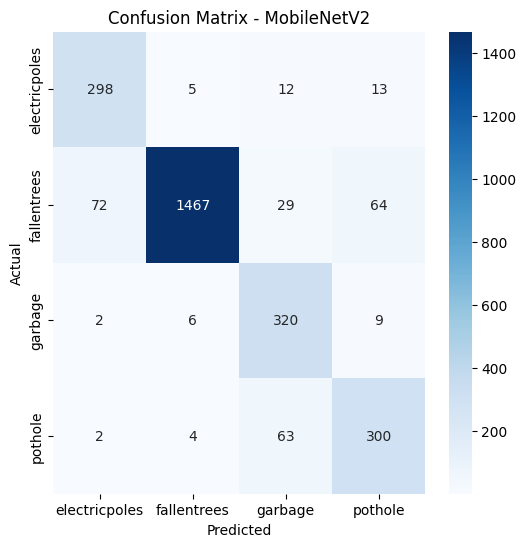

In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

y_true, y_pred = [], []

for x, y in test_ds:
    preds = model.predict(x, verbose=0)
    y_true.extend(np.argmax(y.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - MobileNetV2")
plt.show()

**2.7 SAVE MODEL**

In [ ]:
# ==========================================
# SAVE MODEL TO LOCAL DIRECTORY
# ==========================================
import os

# Save paths
keras_path = os.path.join(MODEL_SAVE_DIR, "image_classifier.keras")
h5_path = os.path.join(MODEL_SAVE_DIR, "image_classifier.h5")

print(f"💾 Saving models to: {MODEL_SAVE_DIR}\n")

try:
    # Save as .keras (Modern format - Recommended)
    model.save(keras_path)
    print(f"✅ Saved: {keras_path}")

    # Save as .h5 (Legacy format - for backend compatibility)
    model.save(h5_path, save_format='h5')
    print(f"✅ Saved: {h5_path}")

except Exception as e:
    print(f"❌ Error saving model: {e}")

print("\n" + "="*50)
print("✅ SUCCESS: Model saved!")
print("="*50)

Starting model export to 2 locations...

[1/2] Saving to: E:\My Programs\smart-civic-system\ml-service\app\models
   - Saved: image_classifier.keras


C:\Users\Hp\anaconda3\envs\civicai\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


   - Saved: image_classifier.h5
[2/2] Saving to: E:\My Programs\civic_issue_classification\Backend\model
   - Saved: image_classifier.keras
   - Saved: image_classifier.h5

✅ SUCCESS: Model export complete!


In [ ]:
# =====================================================
# VERIFY MODEL CAN BE LOADED
# =====================================================

# Test loading the keras model
test_model = tf.keras.models.load_model(keras_path)
print("✅ Model loads successfully!")

# Test with a sample image from test set
test_images, test_labels = next(iter(test_ds))
test_pred = test_model.predict(test_images[0:1], verbose=0)
predicted_class = class_names[np.argmax(test_pred)]

print(f"✅ Prediction works! Sample predicted class: {predicted_class}")
print(f"   Confidence: {np.max(test_pred):.2%}")
print(f"\n✅ Model is ready! TensorFlow version: {tf.__version__}")

✅ Model loads successfully from keras format!
✅ Prediction works! Sample predicted class: electricpoles
   Confidence: 100.00%

✅ Model is fully compatible with TensorFlow 2.15.0 + Keras 2.15.0!


**2.8 TRY ON A SAMPLE IMAGE**

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image

# Load saved model
model = tf.keras.models.load_model(keras_path)

print("✅ Model loaded successfully")




Model loaded successfully


In [ ]:
# Display names (mapped from folder names):
# ['electric_poles', 'fallen_trees', 'garbage', 'miscellaneous', 'pothole']

# Test image path - update this to your test image
if USE_GOOGLE_DRIVE:
    img_path = os.path.join(DRIVE_BASE, "dataset", "trial_image.jpeg")
else:
    img_path = r"E:\My Programs\civic_issue_classification\dataset\trial_image.jpeg"

if os.path.exists(img_path):
    img = image.load_img(img_path, target_size=img_size)
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions)]
    confidence = np.max(predictions) * 100

    # Miscellaneous detection: if confidence is low, might be miscellaneous
    print("🔍 Predicted class:", predicted_class)
    print("📊 Confidence:", f"{confidence:.2f}%")
    
    if confidence < 50 and predicted_class != 'miscellaneous':
        print("⚠️ Low confidence - image might belong to 'miscellaneous' category")
    
    print("\nAll class probabilities:")
    for i, prob in enumerate(predictions[0]):
        print(f"  {class_names[i]}: {prob*100:.2f}%")
else:
    print(f"⚠️ Test image not found at: {img_path}")
    print("Add a trial_image.jpeg to your dataset folder to test.")

1/1 [==============================] - 0s 86ms/step
Predicted class: garbage
Confidence: 99.99%
electricpoles: 0.01%
fallentrees: 0.00%
garbage: 99.99%
pothole: 0.00%


**2.8 FINE-TUNE MODEL**

In [ ]:
# =====================================================
# FINE-TUNING (ADVANCED) - Run after initial training
# =====================================================

# Unfreeze last 20 layers of MobileNetV2
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

print(f"🔓 Unfroze last 20 layers for fine-tuning")
print(f"   Trainable layers: {len([l for l in base_model.layers if l.trainable])}")

# Recompile with lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

# Fine-tune the model
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks_list
)